## Classificatore basato su Support Vector Machine lineari e informazioni linguistiche non lessicali

In [2]:
! pip install scikit-learn
! pip install numpy 
! pip install joblib
! pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 9.2 MB/s eta 0:00:00 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.7/20.7 MB 10.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [1]:
# Import dei moduli utilizzati
import utils_svm
import csv
import numpy as np

In [2]:
# Import delle path dei dati da utilizzare
data_path = "data.json"
profiling_path = "Profiling_UD/16152.csv"

In [3]:
# Loading del dizionario
data = utils_svm.load_data(data_path)

In [4]:
# Funzione per l'aggiunta delle feature trovate da Profiling UD al dizionario
def load_profiling_features(src_path, data):
    """
    Funzione atta a caricare le feature da un file output di Profiling UD
    e ad aggiungerle al dizionario dei dati esistente.

    Args:
        src_path: str, il percorso del file contenente le feature da caricare
        data: dict, dizionario esistente dei dati a cui aggiungere le feature

    Returns:
        features_names: list, lista dei nomi delle feature caricate
        dataset: dict, dizionario aggiornato con le feature per ciascun documento
    """

    features_names = None
    dataset = data

    with open(src_path, 'r') as src_file: 
        csv_reader = csv.reader(src_file, delimiter = '\t')
        for row in csv_reader:
            if features_names is None:
                features_names = row[1:]
            else:
                doc_id = row[0].split('/')[-1][:-len('.conllu')]
                features = [float(el) for el in row[1:]]
                dataset[doc_id]['features'] = features

    return features_names, dataset

In [5]:
# Caricamente delle features
features_names, dataset = load_profiling_features(profiling_path, data)

# Eliminiamo versione precedente del dataset per evitare confusione
del data

In [6]:
print(f'Numero di features: {len(features_names)}')
print('\nLista delle Features')
print(features_names[:10])

Numero di features: 126

Lista delle Features
['n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'upos_dist_ADJ', 'upos_dist_ADP', 'upos_dist_ADV', 'upos_dist_AUX', 'upos_dist_CCONJ', 'upos_dist_DET']


In [7]:
# Controllo di un documento casuale per assicurarsi che sia correttamente formato
doc = 'train_Hugo_376'
print(f'Primo documento, id {doc}')
for key, value in dataset[doc].items():
    print(f'{key}: ', value)

Primo documento, id train_Hugo_376
text:  He directed his steps towards the door. Not a voice was raised, not an arm extended to hinder him. All stood aside. At that moment there was about him that divine something which causes multitudes to stand aside and make way for a man. He traversed the crowd slowly. It was never known who opened the door, but it is certain that he found the door open when he reached it. On arriving there he turned round and said:—
author:  Hugo
split:  train
features:  [7.0, 88.0, 12.571428571428571, 4.1645569620253164, 2.272727272727273, 5.681818181818182, 9.090909090909092, 3.409090909090909, 3.409090909090909, 10.227272727272727, 0.0, 13.636363636363637, 0.0, 3.409090909090909, 17.045454545454547, 0.0, 10.227272727272727, 2.272727272727273, 0.0, 19.318181818181817, 0.0, 0.4936708860759494, 84.61538461538461, 15.384615384615385, 0.0, 100.0, 58.8235294117647, 5.882352941176471, 17.647058823529413, 17.647058823529413, 80.0, 0.0, 0.0, 20.0, 66.66666666666667, 33

In [8]:
# Divisione in train, val e test
train_features, train_labels, val_features, val_labels, test_features, test_labels= utils_svm.train_test_split(dataset, target_label='author')

In [9]:
print('Documenti training set:', len(train_features), len(train_labels))
print('Documenti validation set:', len(val_features), len(val_labels))
print('Documenti test set:', len(test_features), len(test_labels))

Documenti training set: 3600 3600
Documenti validation set: 1500 1500
Documenti test set: 2094 2094


### Trasformazione delle liste in matrici

In [10]:
x_train = np.array(train_features)
y_train = np.array(train_labels)

x_val = np.array(val_features)
y_val = np.array(val_labels)

x_test = np.array(test_features)
y_test = np.array(test_labels)

In [11]:
x_val

array([[16.        , 92.        ,  5.75      , ...,  0.        ,
         0.        ,  0.        ],
       [11.        , 66.        ,  6.        , ...,  0.        ,
         0.        ,  0.        ],
       [15.        , 65.        ,  4.33333333, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 3.        , 62.        , 20.66666667, ...,  0.        ,
         0.        ,  0.        ],
       [ 6.        , 71.        , 11.83333333, ...,  0.        ,
         0.        ,  0.        ],
       [ 4.        , 87.        , 21.75      , ...,  0.        ,
         0.        ,  0.        ]], shape=(1500, 126))

### Normalizzazione delle features

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
# Normalizzazione delle features con MinMax Scaler
scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(x_train)
scaled_X_val = scaler.transform(x_val)
scaled_X_test = scaler.transform(x_test)

In [14]:
# Controlliamo per sicurezza che non ci siano valori NaN poiché in run passate segnalava un warning di overflow e di divisione per zero
# probabilmente però dovuta alla grande quantità di dati
np.isnan(scaled_X_test).sum()
np.isnan(scaled_X_val).sum()
np.isnan(scaled_X_train).sum()

np.int64(0)

## Classificazione

#### Model Selection

In [15]:
# Import dei moduli usati per la task di classificazione
import os
import joblib

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
from sklearn.dummy import DummyClassifier

In [16]:
grid_result = utils_svm.model_selection(scaled_X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear fa

0.7222222222222222


In [17]:
# Modello con migliori parametri
model = LinearSVC(**grid_result.best_params_, max_iter=50000)

In [18]:
# Saving the model
path = "/Users/laviniarotellini/Library/CloudStorage/OneDrive-UniversityofPisa"
filename = os.path.join(path, 'SVM_features.pkl')
joblib.dump(model, filename)

['/Users/laviniarotellini/Library/CloudStorage/OneDrive-UniversityofPisa/SVM_features.pkl']

In [19]:
model = joblib.load('/Users/laviniarotellini/Library/CloudStorage/OneDrive-UniversityofPisa/SVM_features.pkl')

In [20]:
model.get_params

<bound method BaseEstimator.get_params of LinearSVC(C=1, class_weight='balanced', dual=False, fit_intercept=False,
          max_iter=50000, penalty='l1')>

In [21]:
folds = KFold(n_splits= 5, shuffle=True, random_state=42)

In [22]:
# Visualizzazione delle performance del DummyClassifer vs LinearSVC fold per fold
all_y_true = []
all_y_pred = []

for i, (train_ids, test_ids) in enumerate(folds.split(x_train)):

    fold_X_train = scaled_X_train[train_ids]
    fold_y_train = y_train[train_ids]

    fold_X_test = scaled_X_train[test_ids]
    fold_y_test = y_train[test_ids]

    # Training e calcolo accuracy
    kfold_svc = model
    kfold_svc.fit(fold_X_train, fold_y_train)
    fold_y_pred = kfold_svc.predict(fold_X_test)
    print(f"Accuracy sul fold {i}: {accuracy_score(fold_y_test, fold_y_pred)}")

    # Paragone con dummy classifier
    dummy_clf = DummyClassifier(strategy="uniform")
    dummy_clf.fit(fold_X_train, fold_y_train)
    print(f"Accuracy del DummyClassifier sul fold {i}: {dummy_clf.score(fold_X_test, fold_y_test)}")
    
    all_y_true += fold_y_test.tolist()
    all_y_pred += fold_y_pred.tolist()


print(f"\nOverall accuracy: {accuracy_score(all_y_true, all_y_pred)}")

Accuracy sul fold 0: 0.7041666666666667
Accuracy del DummyClassifier sul fold 0: 0.3486111111111111
Accuracy sul fold 1: 0.7361111111111112
Accuracy del DummyClassifier sul fold 1: 0.3236111111111111
Accuracy sul fold 2: 0.7097222222222223
Accuracy del DummyClassifier sul fold 2: 0.32083333333333336
Accuracy sul fold 3: 0.7444444444444445
Accuracy del DummyClassifier sul fold 3: 0.3416666666666667
Accuracy sul fold 4: 0.7152777777777778
Accuracy del DummyClassifier sul fold 4: 0.35694444444444445

Overall accuracy: 0.7219444444444445


              precision    recall  f1-score   support

     Dickens       0.70      0.70      0.70      1200
       Eliot       0.71      0.68      0.69      1200
        Hugo       0.76      0.79      0.77      1200

    accuracy                           0.72      3600
   macro avg       0.72      0.72      0.72      3600
weighted avg       0.72      0.72      0.72      3600



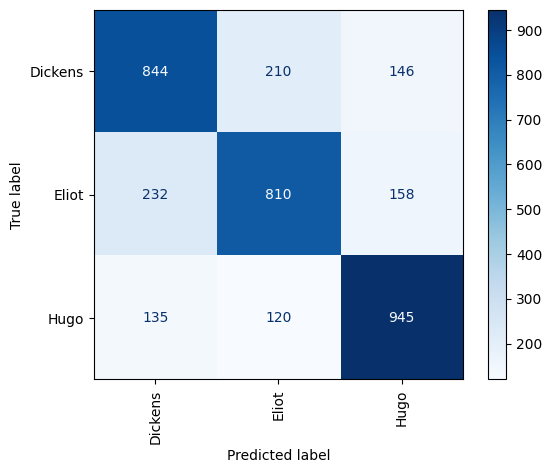

In [23]:
# Controlliamo la performance su tutte le istanze
print(classification_report(all_y_true, all_y_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(all_y_true, all_y_pred, xticks_rotation='vertical', cmap='Blues')

### Validazione del modello

In [24]:
model.fit(scaled_X_train, y_train)

,penalty,'l1'
,loss,'squared_hinge'
,dual,False
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,False
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


Accuracy sul validation set: 0.6446666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.58      0.57      0.58       500
       Eliot       0.59      0.49      0.53       500
        Hugo       0.74      0.87      0.80       500

    accuracy                           0.64      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.64      0.64      0.64      1500



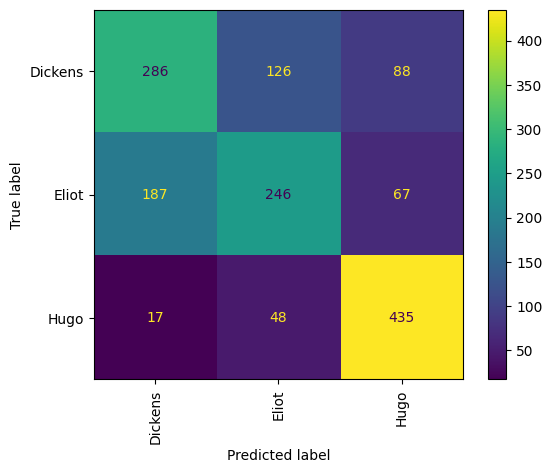

In [25]:
# Performance sul set di validazione
y_val_pred = utils_svm.predict(model, scaled_X_val, y_val, split = 'validation set')

### Predizione sul test set

Accuracy sul test set: 0.6442215854823304
Classification report sul test set:               precision    recall  f1-score   support

     Dickens       0.57      0.64      0.60       698
       Eliot       0.62      0.52      0.57       698
        Hugo       0.74      0.77      0.76       698

    accuracy                           0.64      2094
   macro avg       0.64      0.64      0.64      2094
weighted avg       0.64      0.64      0.64      2094



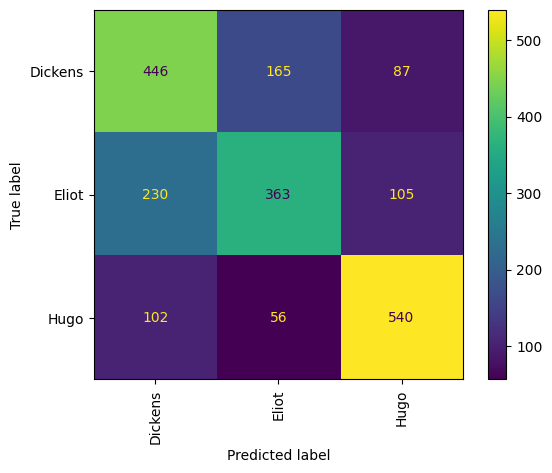

In [26]:
y_pred = utils_svm.predict(model, scaled_X_test, y_test, split='test set')

Accuracy sul DummyClassifier: 0.3433619866284623
Classification report sul DummyClassifier:               precision    recall  f1-score   support

     Dickens       0.34      0.34      0.34       698
       Eliot       0.34      0.34      0.34       698
        Hugo       0.35      0.35      0.35       698

    accuracy                           0.34      2094
   macro avg       0.34      0.34      0.34      2094
weighted avg       0.34      0.34      0.34      2094



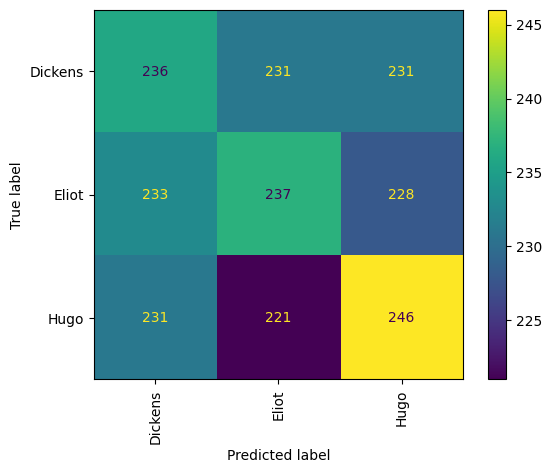

In [27]:
# Performance del DummyClassifier
dummy = DummyClassifier(strategy = 'uniform')
dummy.fit(scaled_X_train, y_train)

y_pred_dummy = utils_svm.predict(dummy, scaled_X_test, y_test, split = 'DummyClassifier')

### Feature Importances

In [28]:
import matplotlib.pyplot as plt

In [29]:
model.classes_

array(['Dickens', 'Eliot', 'Hugo'], dtype='<U7')

In [30]:
coefs = model.coef_
coefs.shape

(3, 126)

In [31]:
num_to_plot = 20

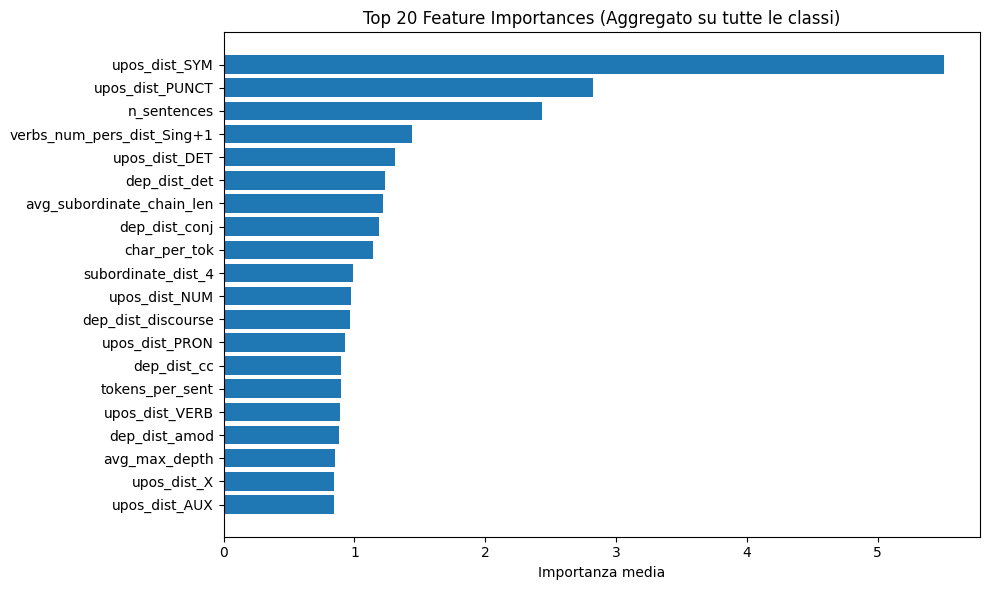

In [32]:
# Plot delle features più importanti per il classificatore

# Recupero nomi e coefficienti
coefs = model.coef_  # shape: (n_classes, n_features)

# Calcolo dell'importanza aggregata: media dei |coefficienti| per feature
mean_abs_importance = np.mean(np.abs(coefs), axis=0)

# Ordina le feature per importanza decrescente
top_indices = np.argsort(mean_abs_importance)[-20:][::-1]
top_features = [features_names[i] for i in top_indices]
top_importances = mean_abs_importance[top_indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(20), top_importances[::-1], align='center')
plt.yticks(range(20), top_features[::-1])
plt.xlabel('Importanza media')
plt.title('Top 20 Feature Importances (Aggregato su tutte le classi)')
plt.tight_layout()
plt.show()

Feature importance classe Eliot


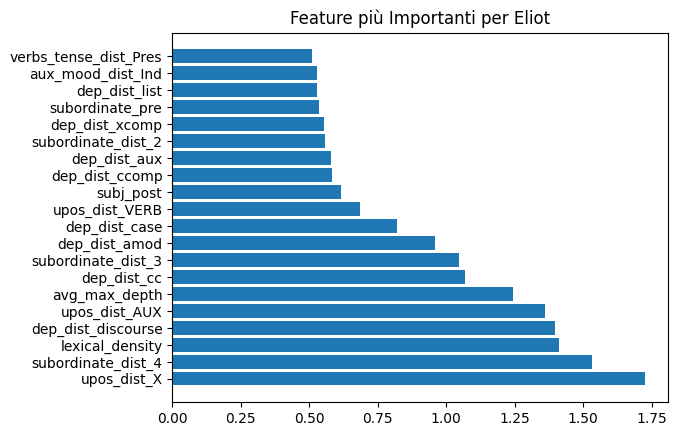

In [33]:
idx_Eliot = 1
class_coefs = coefs[idx_Eliot]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_names, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

# Plot delle features più importanti per Eliot
print(f"Feature importance classe {model.classes_[idx_Eliot]}")
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align = 'center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.title('Feature più Importanti per Eliot')
plt.show()

Feature importance classe Dickens


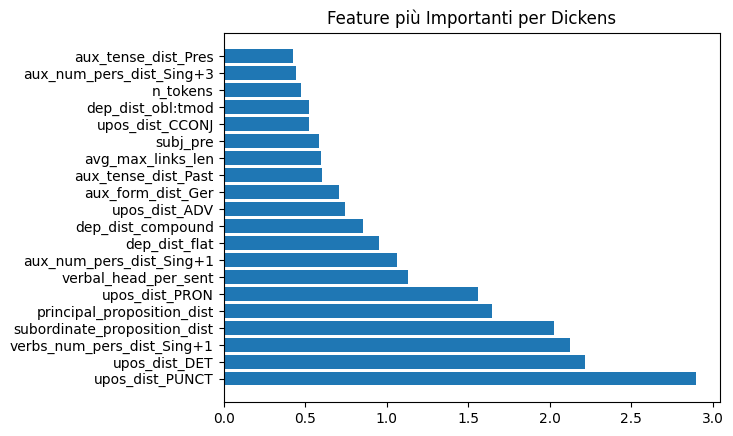

In [34]:
idx_Dickens = 0
class_coefs = coefs[idx_Dickens]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_names, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

# Plot delle features più importanti per Dickens
print(f"Feature importance classe {model.classes_[idx_Dickens]}")
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align = 'center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.title('Feature più Importanti per Dickens')
plt.show()

Feature importance classe Hugo


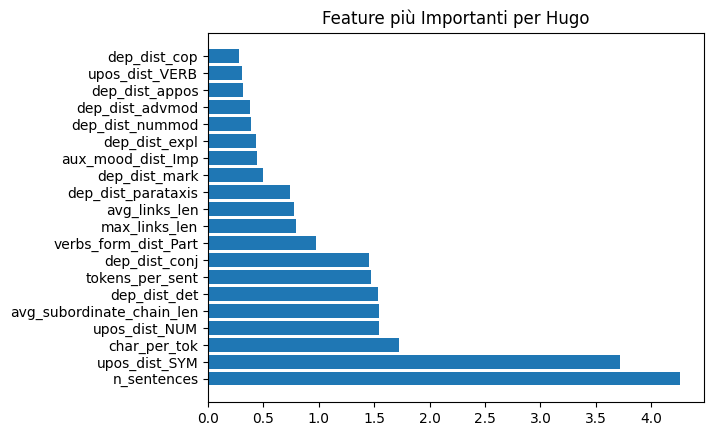

In [35]:
idx_Hugo = 2
class_coefs = coefs[idx_Hugo]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_names, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

# Plot delle features più importanti per Hugo
print(f"Feature importance classe {model.classes_[idx_Hugo]}")
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align = 'center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.title('Feature più Importanti per Hugo')
plt.show()